In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/DS 3000/charging_data_encoded.csv')
print("Raw shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw shape: (1320, 33)


,Battery Capacity (kWh),Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),...,Day of Week_Sunday,Day of Week_Thursday,Day of Week_Tuesday,Day of Week_Wednesday,Charger Type_Level 1,Charger Type_Level 2,User Type_Commuter,User Type_Long-Distance Traveler,start_hour,start_weekday
0,108.463007,60.712346,0.591363,36.389181,13.087717,29.371576,86.119962,293.602111,27.947953,2.0,...,False,False,True,False,False,False,True,False,0,0
1,100.000000,12.339275,3.133652,30.677735,21.128448,10.115778,84.664344,112.112804,14.311026,3.0,...,False,False,False,False,True,False,False,False,1,0
2,75.000000,19.128876,2.452653,27.513593,35.667270,6.854604,69.917615,71.799253,21.002002,2.0,...,False,True,False,False,False,True,True,False,2,0
3,50.000000,79.457824,1.266431,32.882870,13.036239,83.120003,99.624328,199.577785,38.316313,1.0,...,False,False,False,False,True,False,False,True,3,0
4,50.000000,19.629104,2.019765,10.215712,10.161471,54.258950,63.743786,203.661847,-7.834199,1.0,...,False,False,False,False,True,False,False,True,4,0


In [ ]:
# creating target variable
df["delta_SOC"] = df["State of Charge (End %)"] - df["State of Charge (Start %)"]

#ensuring numeric columns are numeric
numeric_cols = [
    "Battery Capacity (kWh)",
    "Energy Consumed (kWh)",
    "Charging Duration (hours)",
    "Charging Rate (kW)",
    "Temperature (°C)",
    "Vehicle Age (years)",
    "Distance Driven (since last charge) (km)"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows with missing target value
df = df.dropna(subset=["delta_SOC"]).reset_index(drop=True)


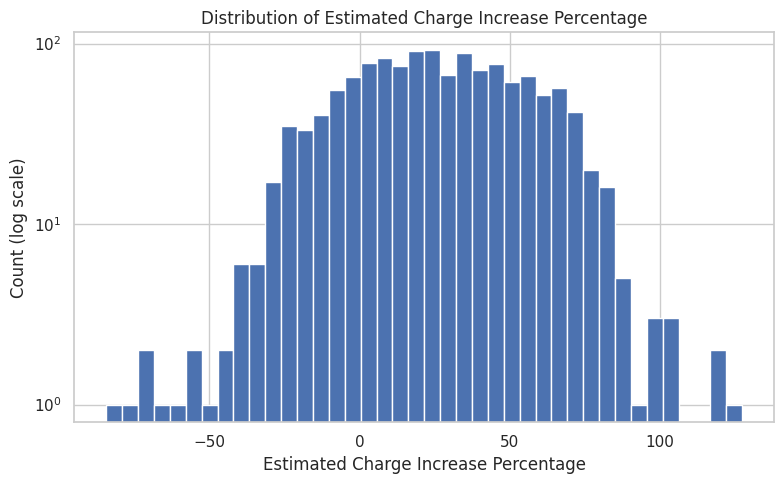

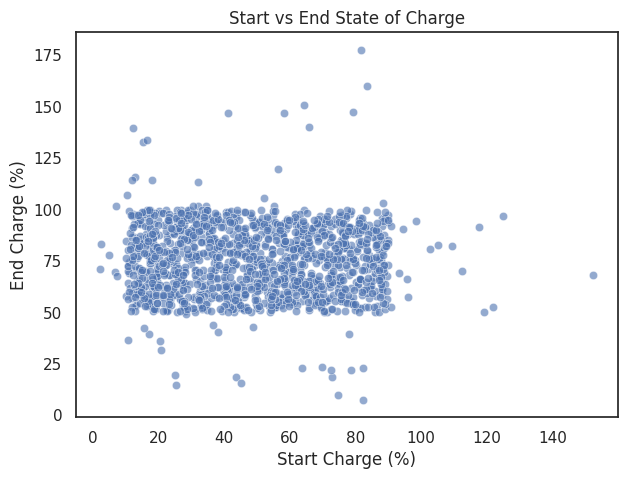

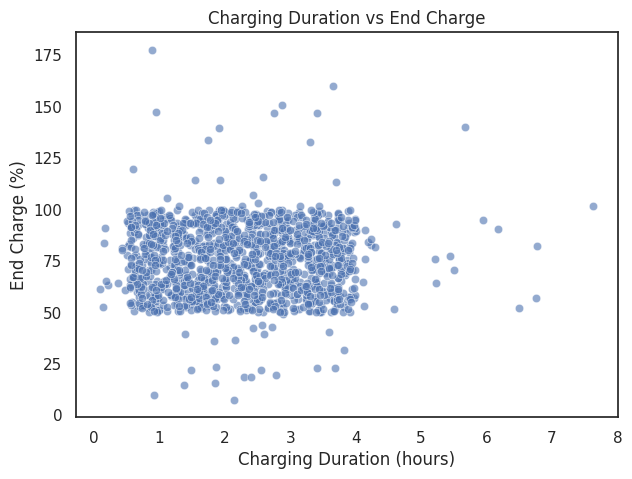

In [ ]:
# Histogram of charge increase percentage
plt.figure(figsize=(8,5))
plt.hist(df["delta_SOC"], bins=40)
plt.yscale("log")
plt.xlabel("Estimated Charge Increase Percentage")
plt.ylabel("Count (log scale)")
plt.title("Distribution of Estimated Charge Increase Percentage")
plt.tight_layout()
plt.show()

# Features we will use
feature_cols = [
    "State of Charge (Start %)",
    "Charging Duration (hours)",
    "Charging Rate (kW)",
    "Battery Capacity (kWh)",
    "Temperature (°C)",
    "Vehicle Age (years)",
    "Distance Driven (since last charge) (km)"
]
target = "delta_SOC"

sns.set(style="white")

plt.figure(figsize=(7,5))
sns.scatterplot(x="State of Charge (Start %)", y="State of Charge (End %)", data=df, alpha=0.6)
plt.xlabel("Start Charge (%)")
plt.ylabel("End Charge (%)")
plt.title("Start vs End State of Charge")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(x="Charging Duration (hours)", y="State of Charge (End %)", data=df, alpha=0.6)
plt.xlabel("Charging Duration (hours)")
plt.ylabel("End Charge (%)")
plt.title("Charging Duration vs End Charge")
plt.show()


In [ ]:
#Feature Matrix for X and Y
X = df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(df[feature_cols].median())
y = df[target]

# ensure numeric & impute
X_encoded = X.apply(pd.to_numeric, errors="coerce")
X_encoded = X_encoded.fillna(X_encoded.median())

print("X_encoded shape:", X_encoded.shape)
X_encoded.head()

X_encoded shape: (1320, 7)


,State of Charge (Start %),Charging Duration (hours),Charging Rate (kW),Battery Capacity (kWh),Temperature (°C),Vehicle Age (years),Distance Driven (since last charge) (km)
0,29.371576,0.591363,36.389181,108.463007,27.947953,2.0,293.602111
1,10.115778,3.133652,30.677735,100.000000,14.311026,3.0,112.112804
2,6.854604,2.452653,27.513593,75.000000,21.002002,2.0,71.799253
3,83.120003,1.266431,32.882870,50.000000,38.316313,1.0,199.577785
4,54.258950,2.019765,10.215712,50.000000,-7.834199,1.0,203.661847


In [ ]:
clean_cols = (
    X_encoded.columns
    .astype(str)
    .str.replace(r"[<>\[\]\(\)]", "_", regex=True)
    .str.replace(r"__+", "_", regex=True)
    .str.strip("_")
)

X_encoded.columns = clean_cols
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (1056, 7) | Test shape: (264, 7)


# Linear Model

In [ ]:
# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Baseline: Multiple Linear Regression
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

pred_train = linreg.predict(X_train_scaled)
pred_test = linreg.predict(X_test_scaled)

baseline_results = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, pred_train)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, pred_test)),
    "Train MAE": mean_absolute_error(y_train, pred_train),
    "Test MAE": mean_absolute_error(y_test, pred_test),
    "R2": r2_score(y_test, pred_test),
}

baseline_results

{'Train RMSE': np.float64(17.061963643882386),
 'Test RMSE': np.float64(17.044992078675865),
 'Train MAE': 13.790886996492274,
 'Test MAE': 13.86106491171039,
 'R2': 0.6838968393138332}

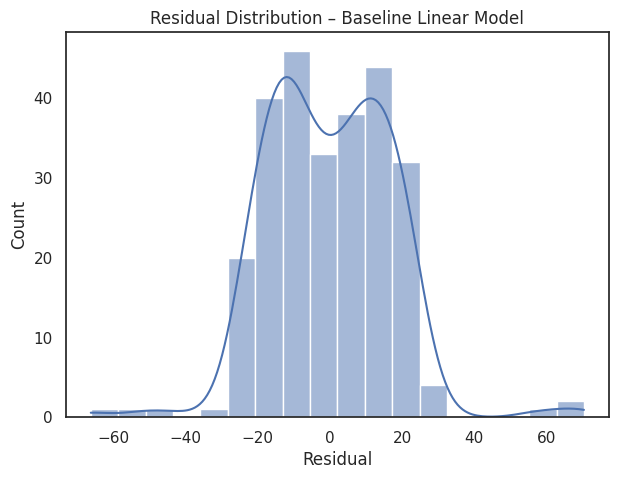

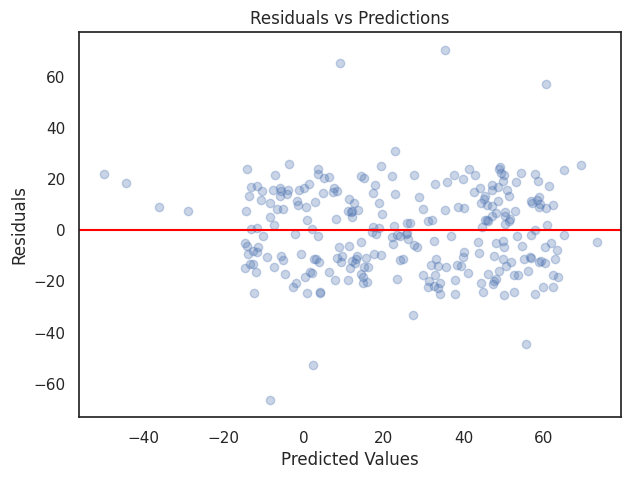

In [ ]:
# Residual plots
residuals = y_test - pred_test

plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution – Baseline Linear Model")
plt.xlabel("Residual")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(pred_test, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

In [ ]:
# Maximum Likelihood
# Negative log-likelihood under Gaussian noise assumption
sigma2 = np.mean(residuals ** 2)
n = len(residuals)

nll = 0.5 * n * np.log(2 * np.pi * sigma2) + np.sum(residuals**2) / (2 * sigma2)
nll

np.float64(1123.26587315299)

# Regularized Models

RIDGE:

In [ ]:
#function for plotting the feature coefficients
def plot_coefficients(model, model_name, X_train):

    # extract coefficients for each feature
    coefs = model.named_steps[list(model.named_steps.keys())[-1]].coef_
    feature_names = X_train.columns

    # build dataframe for feature importance
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefs
    }).sort_values(by='Coefficient', key=abs, ascending=False)

    # plot the coefficients
    plt.figure(figsize=(8,5))
    plt.barh(coef_df['Feature'], coef_df['Coefficient'])
    plt.xlabel("Coefficient Value")
    plt.title(f"{model_name} Feature Coefficients")
    plt.tight_layout()
    plt.show()

    return coef_df

In [ ]:
# create the ridge pipeline (normalizing using standard scaler)
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha = 1.0))
])
ridge_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

In [ ]:
#do 10-fold cv (9 train + 1 test) and return mean-squared-error values
ridge_mse_scores = -cross_val_score(
    ridge_pipeline,
    X_train,
    y_train,
    cv = 10,
    scoring = 'neg_mean_squared_error'
)

#calculate the mean of the 10 cv values
ridge_mean_mse = np.mean(ridge_mse_scores)

#run prediction using the test set
y_pred = ridge_pipeline.predict(X_test)

#get the mean-absolute-error and root-mean-squared-error
ridge_mae = mean_absolute_error(y_test, y_pred)
ridge_rmse = np.sqrt(ridge_mean_mse)


In [ ]:
#print results from initial alpha value model
print("Ridge Regression Performance:")
print("-----------------------------")
print(f"10-fold CV Mean Squared Error (MSE): {ridge_mean_mse:,.2f} minutes²")
print(f"Root Mean Squared Error (RMSE, CV): {ridge_rmse:,.2f} minutes")
print(f"Mean Absolute Error (MAE, test set): {ridge_mae:,.2f} minutes")

Ridge Regression Performance:
-----------------------------
10-fold CV Mean Squared Error (MSE): 295.71 minutes²
Root Mean Squared Error (RMSE, CV): 17.20 minutes
Mean Absolute Error (MAE, test set): 13.86 minutes


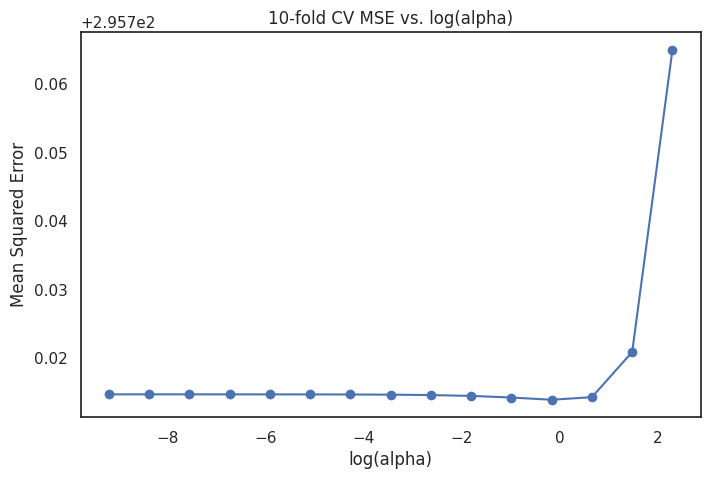

In [ ]:
#create alpha values & empty list
alphas = np.logspace(-4, 1, 15)
ridge_cv_mse_list = []

#get the cv mean-squared-values for each alpha
for al in alphas:
    ridge = Ridge(alpha=al)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', ridge)
    ])
    mse_scores = -cross_val_score(pipeline, X_train, y_train, cv = 10, scoring = 'neg_mean_squared_error')
    #get the mean of the mse's for each fold
    ridge_cv_mse_list.append(np.mean(mse_scores))

#plot the alpha values vs the mse to see best alpha value
plt.figure(figsize=(8,5))
plt.plot(np.log(alphas), ridge_cv_mse_list, marker = 'o')
plt.xlabel('log(alpha)')
plt.ylabel('Mean Squared Error')
plt.title('10-fold CV MSE vs. log(alpha)')
plt.show()

In [ ]:
#find the index of the smallest mse value
best_index = np.argmin(ridge_cv_mse_list)

#find the related alpha value
best_alpha = alphas[best_index]

print("Best actual regularization parameter (alpha):", best_alpha)
print("Corresponding 10-fold CV MSE:", ridge_cv_mse_list[best_index])


Best actual regularization parameter (alpha): 0.8483428982440726
Corresponding 10-fold CV MSE: 295.71394966486343


In [ ]:
#retrain using the calculated best alpha value
ridge_best = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])
ridge_best.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('ridge', Ridge(alpha=np.float64(0.8483428982440726)))])

In [ ]:
# predictions using the new model
y_pred = ridge_best.predict(X_test)

# metrics for the new ridge model
ridge_mse_test = mean_squared_error(y_test, y_pred)
ridge_rmse_test = np.sqrt(ridge_mse_test)
ridge_mae_test = mean_absolute_error(y_test, y_pred)
ridge_r2_test = r2_score(y_test, y_pred)

print(f"Ridge Test Set Performance Values:")
print(f"RMSE: {ridge_rmse_test:.2f} minutes")
print(f"MAE: {ridge_mae_test:.2f} minutes")
print(f"R²: {ridge_r2_test:.3f}")

Ridge Test Set Performance Values:
RMSE: 17.04 minutes
MAE: 13.86 minutes
R²: 0.684


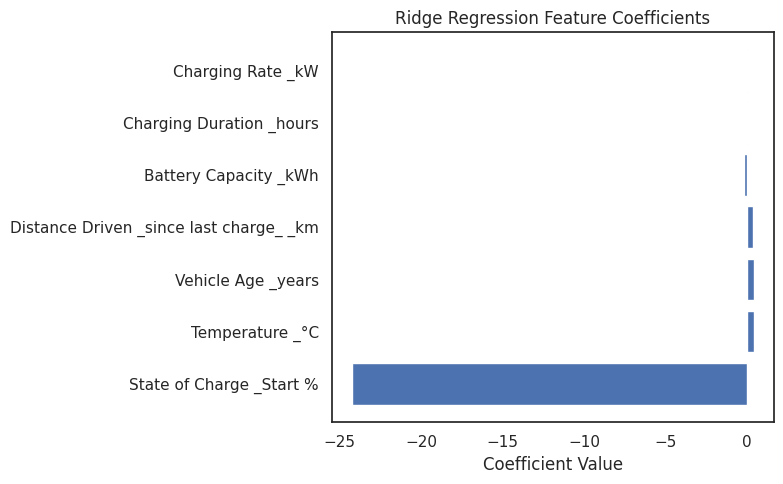

,Feature,Coefficient
0,State of Charge _Start %,-24.238345
4,Temperature _°C,0.426575
5,Vehicle Age _years,0.417505
6,Distance Driven _since last charge_ _km,0.395188
3,Battery Capacity _kWh,-0.178291
1,Charging Duration _hours,0.062680
2,Charging Rate _kW,0.059432


In [ ]:
# call the plot coefficient function
plot_coefficients(ridge_best, "Ridge Regression", X_train)

#positive values increase estimated charge time
#negative values decrease estimated charging time

LASSO:

In [ ]:
# create the ridge pipeline (normalizing using standard scaler)
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1))
])

lasso_pipeline.fit(X_train, y_train)

#do 10-fold cv (9 train + 1 test) and return mean-squared-error values
lasso_mse_scores = -cross_val_score(
    lasso_pipeline,
    X_train,
    y_train,
    cv = 10,
    scoring = 'neg_mean_squared_error'
)

#calculate the mean of the 10 cv values
lasso_mean_mse = np.mean(lasso_mse_scores)

#run prediction using the test set
y_pred = lasso_pipeline.predict(X_test)

#get the mean-absolute-error and root-mean-squared-error
lasso_mae = mean_absolute_error(y_test, y_pred)
lasso_rmse = np.sqrt(lasso_mean_mse)


In [ ]:
#print results from initial alpha value model
print("Lasso Regression Performance:")
print("-----------------------------")
print(f"10-fold CV Mean Squared Error (MSE): {lasso_mean_mse:,.2f} minutes²")
print(f"Root Mean Squared Error (RMSE, CV): {lasso_rmse:,.2f} minutes")
print(f"Mean Absolute Error (MAE, test set): {lasso_mae:,.2f} minutes")

Lasso Regression Performance:
-----------------------------
10-fold CV Mean Squared Error (MSE): 295.03 minutes²
Root Mean Squared Error (RMSE, CV): 17.18 minutes
Mean Absolute Error (MAE, test set): 13.84 minutes


In [ ]:
# get coefficients for each feature in trained lasso model
lasso_coefs = lasso_pipeline.named_steps['lasso'].coef_

#get features where the coefficient is zero
zeroed_features = X_train.columns[lasso_coefs == 0]
print("Features set to zero by Lasso:", list(zeroed_features))

Features set to zero by Lasso: ['Charging Duration _hours', 'Charging Rate _kW']


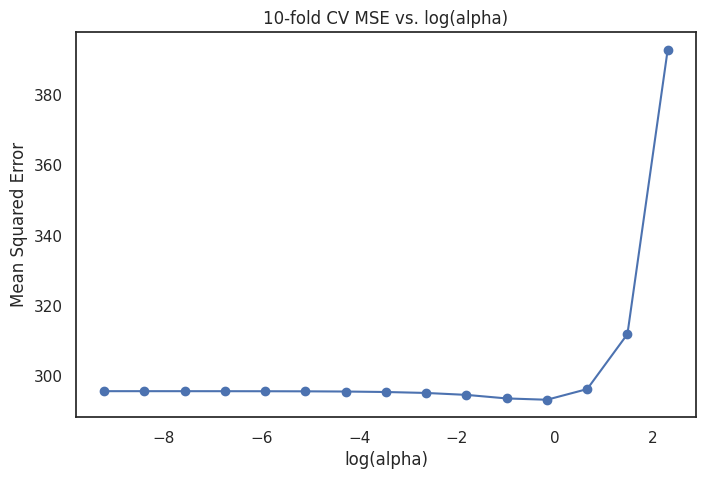

Best Lasso alpha: 0.8483428982440726
Corresponding 10-fold CV MSE: 293.2711935856513


In [ ]:
#create alpha values & empty list
alphas = np.logspace(-4, 1, 15)
lasso_cv_mse_list = []

#get the cv mean-squared-values for each alpha
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', lasso)
    ])
    mse_scores = -cross_val_score(pipeline, X_train, y_train, cv = 10, scoring = 'neg_mean_squared_error')
    #get the mean of the mse's for each fold
    lasso_cv_mse_list.append(np.mean(mse_scores))

#plot the alpha values vs the mse to see best alpha value
plt.figure(figsize=(8,5))
plt.plot(np.log(alphas), lasso_cv_mse_list, marker = 'o')
plt.xlabel('log(alpha)')
plt.ylabel('Mean Squared Error')
plt.title('10-fold CV MSE vs. log(alpha)')
plt.show()

#find the index of the smallest mse value
best_index = np.argmin(lasso_cv_mse_list)

#find the related alpha value
best_alpha = alphas[best_index]

print("Best Lasso alpha:", best_alpha)
print("Corresponding 10-fold CV MSE:", lasso_cv_mse_list[best_index])

In [ ]:
#retrain using the calculated best alpha value
lasso_best = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=best_alpha, max_iter=10000))
])
lasso_best.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 Lasso(alpha=np.float64(0.8483428982440726), max_iter=10000))])

In [ ]:
# predictions using the new model
y_pred = lasso_best.predict(X_test)

# metrics for new lasso model
lasso_mse_test = mean_squared_error(y_test, y_pred)
lasso_rmse_test = np.sqrt(lasso_mse_test)
lasso_mae_test = mean_absolute_error(y_test, y_pred)
lasso_r2_test = r2_score(y_test, y_pred)

print(f"Lasso Test Set Performance:")
print(f"RMSE: {lasso_rmse_test:.2f} minutes")
print(f"MAE: {lasso_mae_test:.2f} minutes")
print(f"R²: {lasso_r2_test:.3f}")

#get features where the coefficient is zero again for new model
lasso_coefs = lasso_best.named_steps['lasso'].coef_
zeroed_features = X_train.columns[lasso_coefs == 0]
print("Features set to zero by Lasso:", list(zeroed_features))

Lasso Test Set Performance:
RMSE: 17.05 minutes
MAE: 13.82 minutes
R²: 0.684
Features set to zero by Lasso: ['Charging Duration _hours', 'Charging Rate _kW', 'Battery Capacity _kWh', 'Temperature _°C', 'Vehicle Age _years', 'Distance Driven _since last charge_ _km']


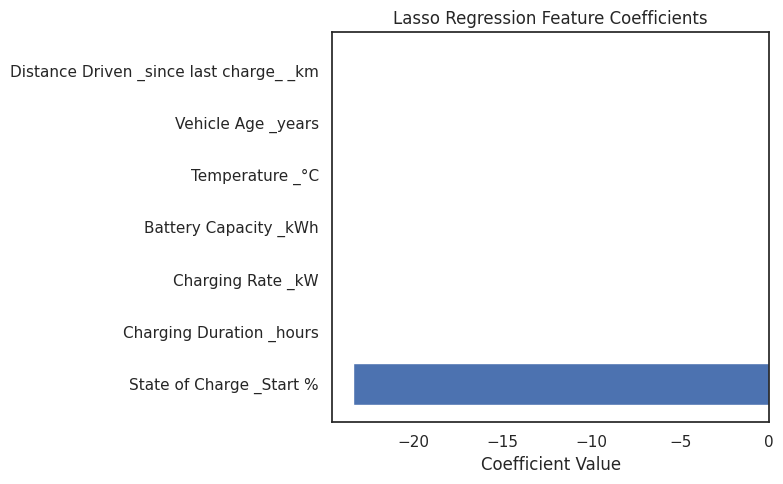

,Feature,Coefficient
0,State of Charge _Start %,-23.411069
1,Charging Duration _hours,0.000000
2,Charging Rate _kW,0.000000
3,Battery Capacity _kWh,-0.000000
4,Temperature _°C,0.000000
5,Vehicle Age _years,0.000000
6,Distance Driven _since last charge_ _km,0.000000


In [ ]:
# call the plot coefficient function
plot_coefficients(lasso_best, "Lasso Regression", X_train)

ELASTIC NET:

In [ ]:
# create elastic net pipeline with standard scaler normalization
elastic_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('elastic', ElasticNet())
])

# values for regularzation strength
# values for l1 ratio (0 = pure ridge & 1 = pure lasso)
param_grid = {
    'elastic__alpha': [0.01, 0.1, 1, 10],
    'elastic__l1_ratio': [0.1, 0.5, 0.7, 1.0]
}

# GridSearchCV tries all the combos of alpha and l1 ratio values
grid = GridSearchCV(elastic_pipe, param_grid, cv=10, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

#retrieves model with the best parameters
elastic_best_model = grid.best_estimator_

#use the best model to predict
y_pred = elastic_best_model.predict(X_test)

# get metrics for the new model
elastic_mse_test = mean_squared_error(y_test, y_pred)
elastic_rmse_test = np.sqrt(elastic_mse_test)
elastic_mae_test = mean_absolute_error(y_test, y_pred)
elastic_r2_test = r2_score(y_test, y_pred)

print(f"Elastic Net Test Set Performance:")
print(f"RMSE: {elastic_rmse_test:.2f} minutes")
print(f"MAE: {elastic_mae_test:.2f} minutes")
print(f"R²: {elastic_r2_test:.3f}")
print("Best Hyperparameters:", grid.best_params_)

Elastic Net Test Set Performance:
RMSE: 17.05 minutes
MAE: 13.81 minutes
R²: 0.684
Best Hyperparameters: {'elastic__alpha': 1, 'elastic__l1_ratio': 1.0}


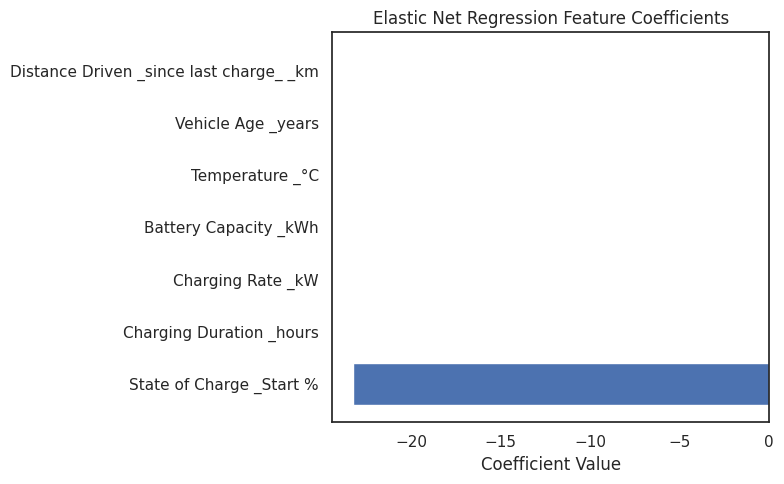

,Feature,Coefficient
0,State of Charge _Start %,-23.259412
1,Charging Duration _hours,0.000000
2,Charging Rate _kW,0.000000
3,Battery Capacity _kWh,-0.000000
4,Temperature _°C,0.000000
5,Vehicle Age _years,0.000000
6,Distance Driven _since last charge_ _km,0.000000


In [ ]:
# call the plot coefficient function
plot_coefficients(elastic_best_model, "Elastic Net Regression", X_train)

In [ ]:
# get best score from grid search
best_cv_mse = -grid.best_score_

#get mean-squared-error
elastic_cv_rmse = np.sqrt(best_cv_mse)

print(f"Elastic Net Best CV MSE:  {best_cv_mse:.2f}")
print(f"Elastic Net Best CV RMSE: {elastic_cv_rmse:.2f} minutes")

Elastic Net Best CV MSE:  293.55
Elastic Net Best CV RMSE: 17.13 minutes


In [ ]:
#print all the results from the three models
results_df = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Elastic Net'],
    'CV RMSE': [ridge_rmse, lasso_rmse, elastic_cv_rmse],
    'Test RMSE': [ridge_rmse_test, lasso_rmse_test, elastic_rmse_test],
    'Test MAE': [ridge_mae_test, lasso_mae_test, elastic_mae_test],
    'Test R²': [ridge_r2_test, lasso_r2_test, elastic_r2_test]
})

print(results_df)

         Model    CV RMSE  Test RMSE   Test MAE   Test R²
0        Ridge  17.196334  17.044763  13.860143  0.683905
1        Lasso  17.176577  17.047239  13.815918  0.683814
2  Elastic Net  17.133444  17.053420  13.814564  0.683584


# Tree Model

In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    mse_train = mean_squared_error(y_tr, y_pred_train)
    mse_test  = mean_squared_error(y_te, y_pred_test)

    rmse_train = np.sqrt(mse_train)
    rmse_test  = np.sqrt(mse_test)
    mae_test   = mean_absolute_error(y_te, y_pred_test)
    r2_test    = r2_score(y_te, y_pred_test)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"RMSE train: {rmse_train:.3f}")
    print(f"RMSE test : {rmse_test:.3f}")
    print(f"MAE test  : {mae_test:.3f}")
    print(f"R² test   : {r2_test:.3f}")

    return {
        "model": name,
        "RMSE_train": rmse_train,
        "RMSE_test": rmse_test,
        "MAE_test": mae_test,
        "R2_test": r2_test
    }

results = []


Fitting 3 folds for each of 45 candidates, totalling 135 fits

Decision Tree
-------------
RMSE train: 17.188
RMSE test : 17.891
MAE test  : 14.332
R² test   : 0.652


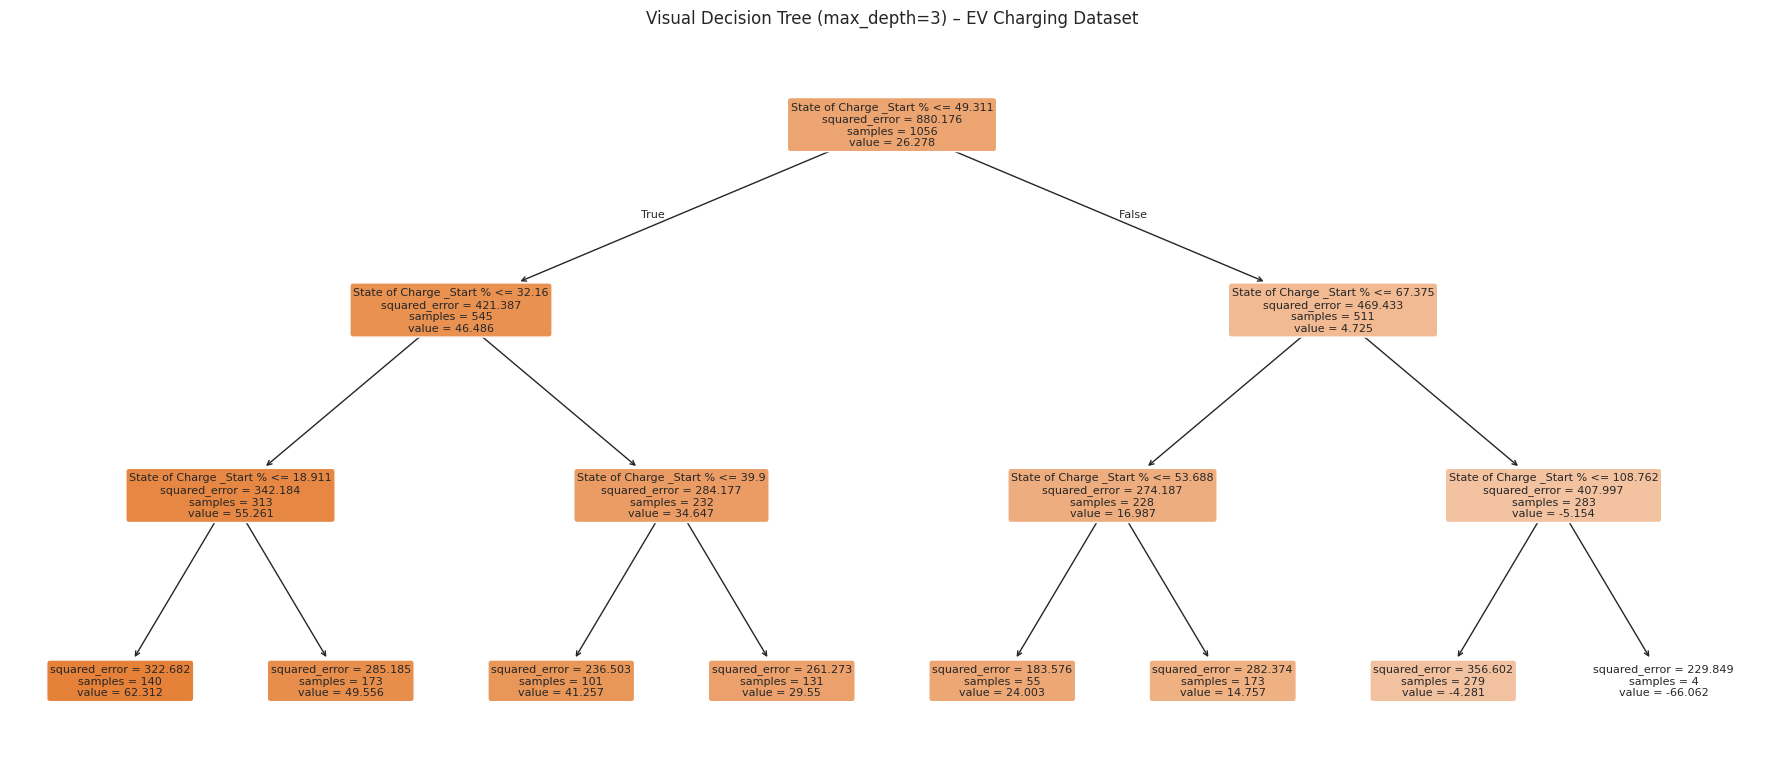

In [ ]:
dt = DecisionTreeRegressor(random_state=42)

dt_params = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10]
}

dt_grid = GridSearchCV(
    dt, dt_params,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_

dt_results = evaluate_model(
    "Decision Tree", best_dt,
    X_train, y_train, X_test, y_test
)
results.append(dt_results)

# ---- visual tree with our dataset (small depth) ----
vis_dt = DecisionTreeRegressor(max_depth=3, random_state=42)
vis_dt.fit(X_train, y_train)

plt.figure(figsize=(18, 8))
plot_tree(
    vis_dt,
    feature_names=X_encoded.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Visual Decision Tree (max_depth=3) – EV Charging Dataset")
plt.tight_layout()
plt.show()

In [ ]:
rf_train_sample = X_train.sample(frac=0.3, random_state=42)
rf_y_sample = y_train.loc[rf_train_sample.index]
print("Random Forest tuning sample size:", rf_train_sample.shape)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf, rf_params,
    n_iter=6,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_search.fit(rf_train_sample, rf_y_sample)
print("Best RF params:", rf_search.best_params_)

best_rf = RandomForestRegressor(
    **rf_search.best_params_,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)

rf_results = evaluate_model(
    "Random Forest", best_rf,
    X_train, y_train, X_test, y_test
)
results.append(rf_results)


Random Forest tuning sample size: (317, 7)
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best RF params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Random Forest
-------------
RMSE train: 6.839
RMSE test : 18.351
MAE test  : 14.433
R² test   : 0.634


Gradient Boosting tuning sample size: (317, 7)
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best GB params: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100}

Gradient Boosting
-----------------
RMSE train: 16.710
RMSE test : 17.287
MAE test  : 13.913
R² test   : 0.675


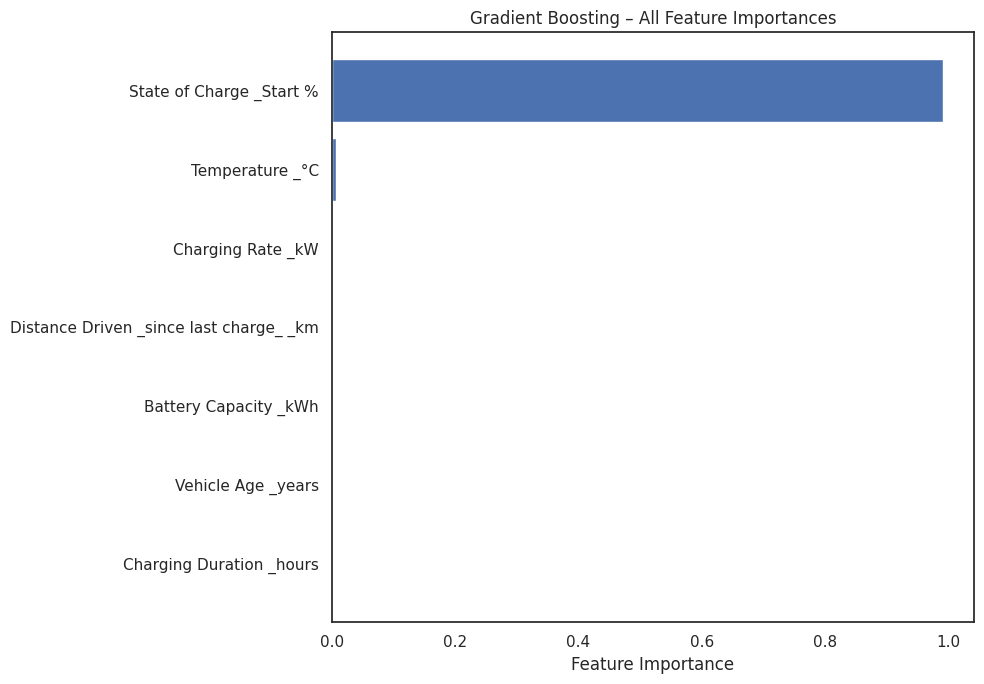

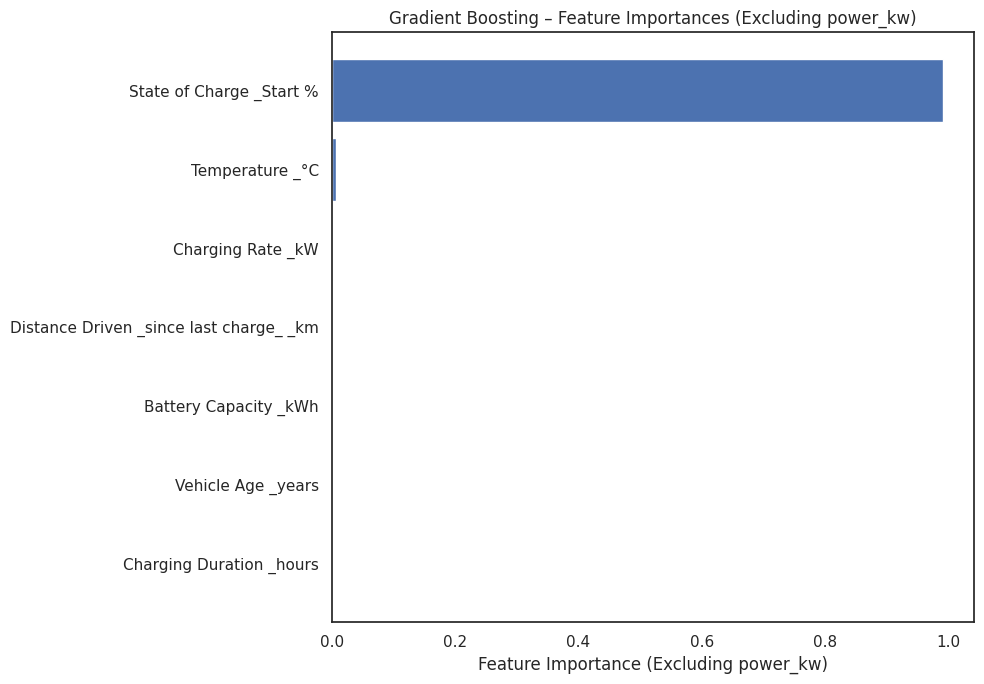

In [ ]:
gb_train_sample = X_train.sample(frac=0.3, random_state=42)
gb_y_sample = y_train.loc[gb_train_sample.index]
print("Gradient Boosting tuning sample size:", gb_train_sample.shape)

gbr = GradientBoostingRegressor(random_state=42)

gbr_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.1],
    "max_depth": [2, 3]
}

gbr_grid = GridSearchCV(
    gbr, gbr_params,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)
gbr_grid.fit(gb_train_sample, gb_y_sample)
print("Best GB params:", gbr_grid.best_params_)

best_gbr = GradientBoostingRegressor(
    **gbr_grid.best_params_,
    random_state=42
)
best_gbr.fit(X_train, y_train)

gbr_results = evaluate_model(
    "Gradient Boosting", best_gbr,
    X_train, y_train, X_test, y_test
)
results.append(gbr_results)

# Gradient Boosting Feature Importances
importances_gbr = best_gbr.feature_importances_
feature_names_gbr = X_encoded.columns

# Sort features by importance
sorted_indices = np.argsort(importances_gbr)[::-1]
sorted_importances = importances_gbr[sorted_indices]
sorted_names = feature_names_gbr[sorted_indices]

# Plot all feature importances
plt.figure(figsize=(10, 7))
plt.barh(range(len(sorted_importances)), sorted_importances[::-1])
plt.yticks(range(len(sorted_importances)), sorted_names[::-1])
plt.xlabel("Feature Importance")
plt.title("Gradient Boosting – All Feature Importances")
plt.tight_layout()
plt.show()

# Plot feature importances excluding 'power_kw' for better visibility of other features
try:
    # Create a mask to exclude 'power_kw'
    mask = np.array([name != 'power_kw' for name in feature_names_gbr])

    importances_gbr_no_power_kw = importances_gbr[mask]
    feature_names_gbr_no_power_kw = feature_names_gbr[mask]

    # Sort the remaining features
    sorted_indices_no_power_kw = np.argsort(importances_gbr_no_power_kw)[::-1]
    sorted_importances_no_power_kw = importances_gbr_no_power_kw[sorted_indices_no_power_kw]
    sorted_names_no_power_kw = feature_names_gbr_no_power_kw[sorted_indices_no_power_kw]

    if len(sorted_importances_no_power_kw) > 0:
        plt.figure(figsize=(10, 7))
        plt.barh(range(len(sorted_importances_no_power_kw)), sorted_importances_no_power_kw[::-1])
        plt.yticks(range(len(sorted_importances_no_power_kw)), sorted_names_no_power_kw[::-1])
        plt.xlabel("Feature Importance (Excluding power_kw)")
        plt.title("Gradient Boosting – Feature Importances (Excluding power_kw)")
        plt.tight_layout()
        plt.show()
    else:
        print("No features remaining after excluding 'power_kw' for plotting.")

except ValueError:
    print("'power_kw' not found in feature names, skipping exclusion plot.")

In [ ]:
try:
    from xgboost import XGBRegressor

    xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    xgb.fit(X_train, y_train)

    xgb_results = evaluate_model(
        "XGBoost", xgb,
        X_train, y_train, X_test, y_test
    )
    results.append(xgb_results)

except ImportError:
    xgb = None
    print("XGBoost not installed. Skipping.")


XGBoost
-------
RMSE train: 9.774
RMSE test : 18.902
MAE test  : 15.077
R² test   : 0.611


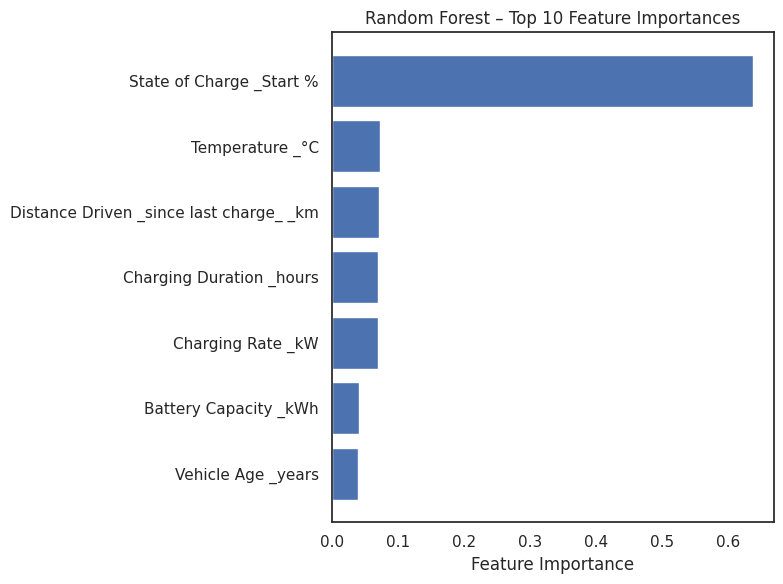

In [ ]:
#Random Foresr Top 10 Features
importances = best_rf.feature_importances_
feature_names = X_encoded.columns

indices = np.argsort(importances)[::-1]
top_n = 10
top_indices = indices[:top_n]
top_importances = importances[top_indices]
top_names = feature_names[top_indices]

plt.figure(figsize=(8, 6))
plt.barh(range(len(top_importances)), top_importances[::-1])
plt.yticks(range(len(top_importances)), top_names[::-1])
plt.xlabel("Feature Importance")
plt.title("Random Forest – Top 10 Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
print(X_encoded.columns.tolist())

['State of Charge _Start %', 'Charging Duration _hours', 'Charging Rate _kW', 'Battery Capacity _kWh', 'Temperature _°C', 'Vehicle Age _years', 'Distance Driven _since last charge_ _km']


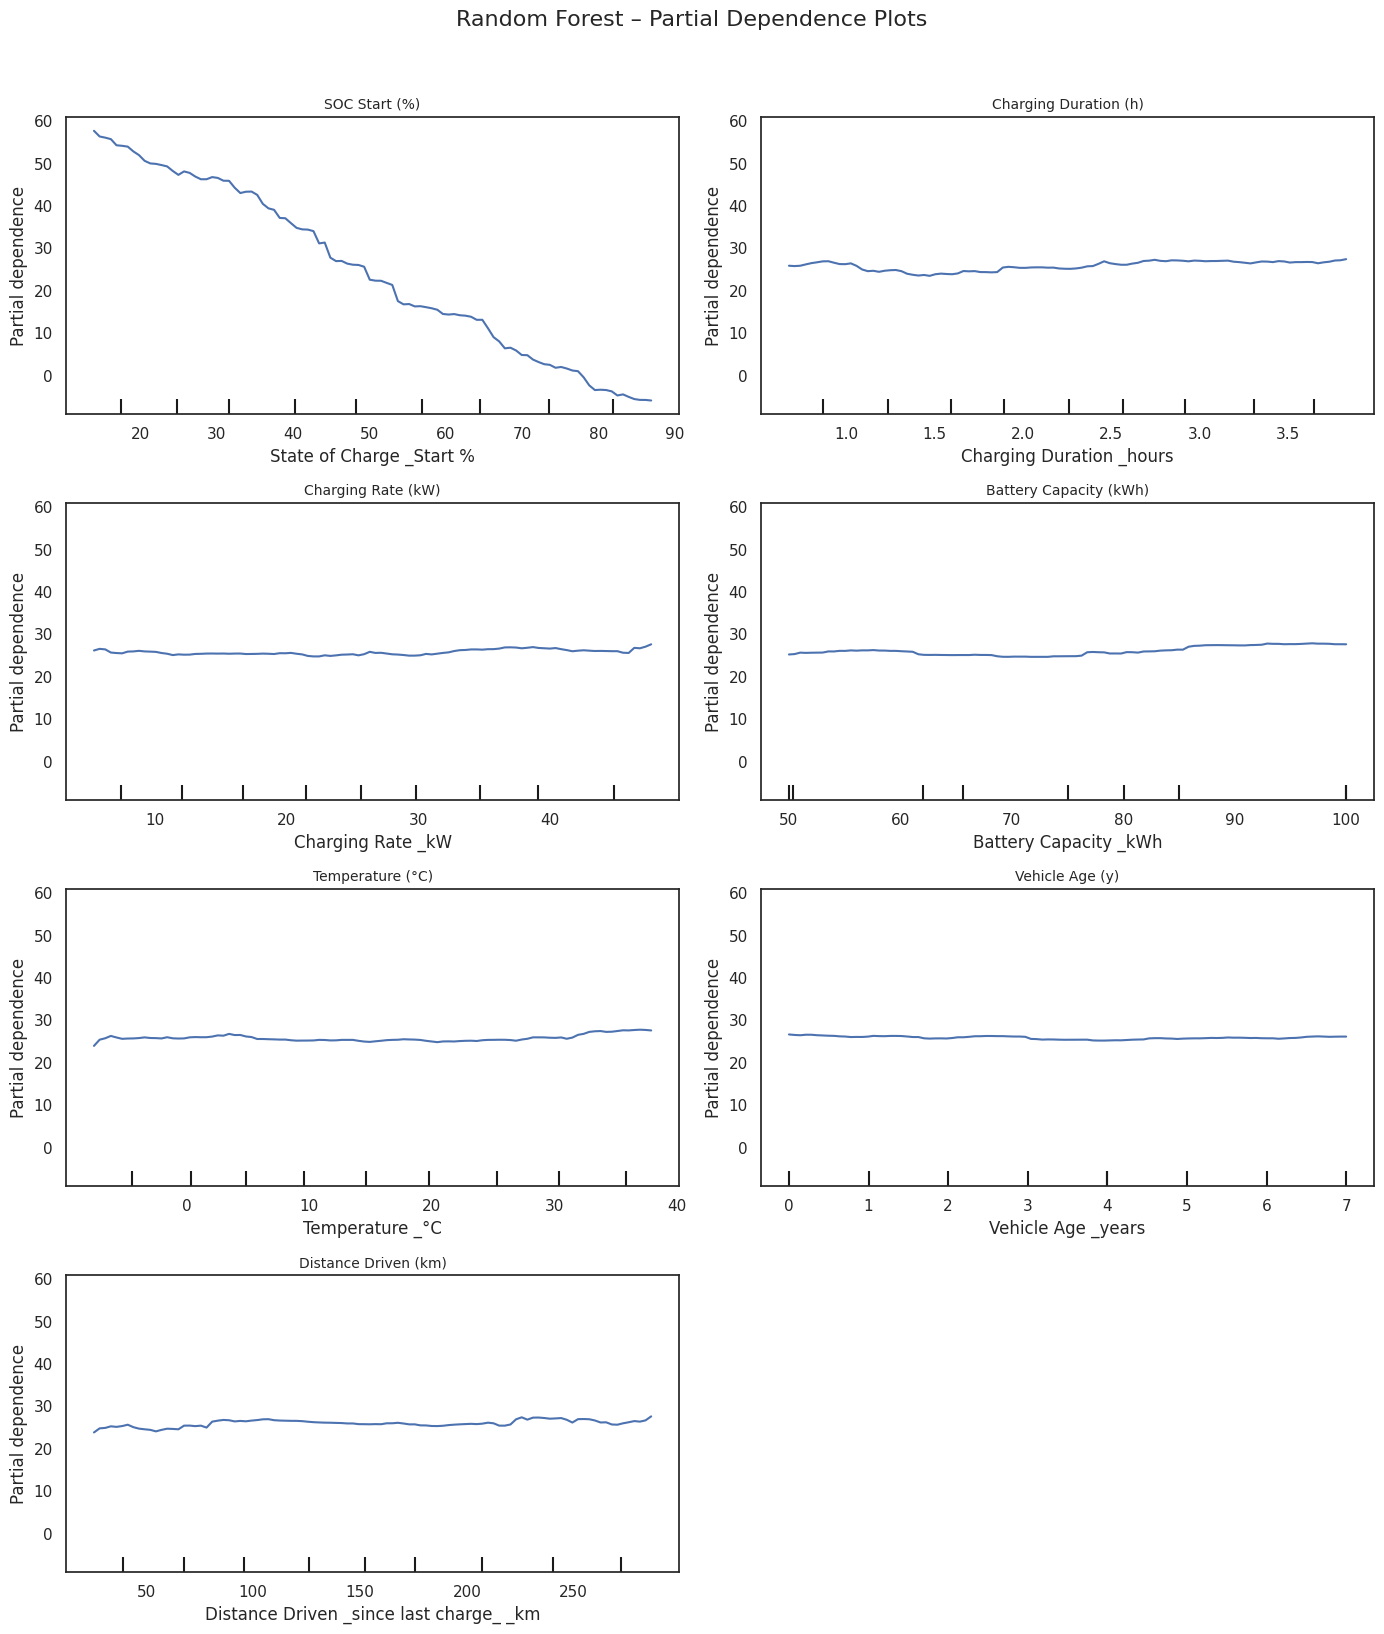

In [ ]:
# Features for PDP
features_for_pdp = [
    'State of Charge _Start %',
    'Charging Duration _hours',
    'Charging Rate _kW',
    'Battery Capacity _kWh',
    'Temperature _°C',
    'Vehicle Age _years',
    'Distance Driven _since last charge_ _km'
]

# Shorten feature names for better subplot readability
feature_labels = [
    "SOC Start (%)",
    "Charging Duration (h)",
    "Charging Rate (kW)",
    "Battery Capacity (kWh)",
    "Temperature (°C)",
    "Vehicle Age (y)",
    "Distance Driven (km)"
]

# Set up grid: 4 rows, 2 columns (will leave last subplot empty)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

# Plot PDPs into the grid
PartialDependenceDisplay.from_estimator(
    best_rf,          # your trained Random Forest model
    X_encoded,        # your feature matrix
    features_for_pdp,
    kind="average",
    ax=axes[:len(features_for_pdp)]  # fill only the needed axes
)

# Set readable titles
for ax, label in zip(axes, feature_labels):
    ax.set_title(label, fontsize=10)

# Turn off the last empty subplot
if len(features_for_pdp) < len(axes):
    for ax in axes[len(features_for_pdp):]:
        ax.axis('off')

plt.suptitle("Random Forest – Partial Dependence Plots", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
results_df = pd.DataFrame(results)
results_df.to_csv("tree_models_performance.csv", index=False)

print("\nSaved performance table → tree_models_performance.csv")
display(results_df)


Saved performance table → tree_models_performance.csv


,model,RMSE_train,RMSE_test,MAE_test,R2_test
0,Decision Tree,17.188367,17.891119,14.331748,0.651735
1,Random Forest,6.839119,18.350716,14.432583,0.633612
2,Gradient Boosting,16.709911,17.286530,13.913263,0.674875
3,XGBoost,9.774453,18.901838,15.077149,0.611274


In [ ]:
results_df_new = pd.DataFrame(results)
# Drop duplicate model entries, keeping the last (most recent) run for each model name
results_df_new = results_df_new.drop_duplicates(subset=['model'], keep='last')
print("Model Performance Comparison (with and without new features, cleaned):")
display(results_df_new)

Model Performance Comparison (with and without new features, cleaned):


,model,RMSE_train,RMSE_test,MAE_test,R2_test
0,Decision Tree,17.188367,17.891119,14.331748,0.651735
1,Random Forest,6.839119,18.350716,14.432583,0.633612
2,Gradient Boosting,16.709911,17.286530,13.913263,0.674875
3,XGBoost,9.774453,18.901838,15.077149,0.611274


In [ ]:
y_pred_rf = best_rf.predict(X_test)
print("Random Forest predictions generated.")

Random Forest predictions generated.


In [ ]:
y_pred_rf_series = pd.Series(y_pred_rf, index=y_test.index)
sample_indices = y_test.sample(n=10, random_state=42).index
comparison_df = pd.DataFrame({
    'Actual': y_test.loc[sample_indices],
    'Predicted': y_pred_rf_series.loc[sample_indices]
})
print("Sample of Actual vs. Predicted Charging Times:")
display(comparison_df)

Sample of Actual vs. Predicted Charging Times:


,Actual,Predicted
1304,12.967100,40.677503
113,19.720164,11.567761
767,9.712435,13.810932
163,4.377859,14.003932
532,23.532141,8.524959
552,56.661279,61.400466
759,10.495142,8.065800
567,-25.931695,-2.499807
506,54.773623,43.999827
826,4.842816,-8.649145


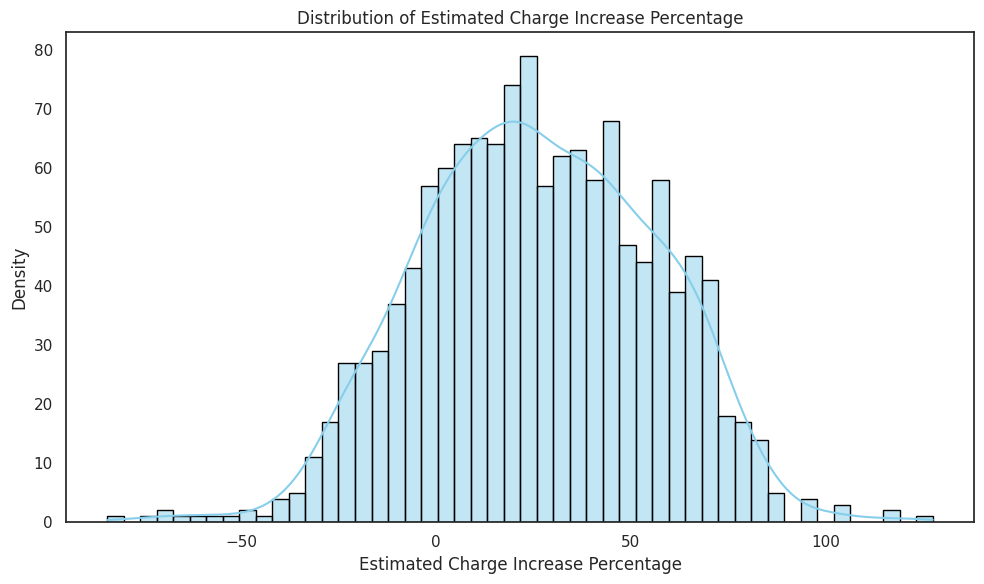

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df["delta_SOC"], bins=50, kde=True, color='skyblue', edgecolor='black')
plt.xlabel("Estimated Charge Increase Percentage")
plt.ylabel("Density")
plt.title("Distribution of Estimated Charge Increase Percentage")
plt.tight_layout()
plt.show()

#Model Evaluation and Comparisons

In [ ]:
# columns for the final comparison table
cols = ["Model", "Type", "CV_RMSE", "Test_RMSE", "Test_MAE", "Test_R2"]

# linear and regularized models
rows = [
    ["Linear Regression (baseline)", "Linear", np.nan, baseline_results["Test RMSE"], baseline_results["Test MAE"], baseline_results["R2"]],
    ["Ridge", "Regularized", ridge_rmse, ridge_rmse_test, ridge_mae_test, ridge_r2_test],
    ["Lasso", "Regularized", lasso_rmse, lasso_rmse_test, lasso_mae_test, lasso_r2_test],
    ["Elastic Net", "Regularized", elastic_cv_rmse, elastic_rmse_test, elastic_mae_test, elastic_r2_test],
]

# append tree based models from results_df_new
for _, r in results_df_new.iterrows():
    rows.append([
        r["model"],
        "Tree-based",
        np.nan,
        r["RMSE_test"],
        r["MAE_test"],
        r["R2_test"],
    ])

# build dataframe from rows, sort by Test_RMSE (best model first), and reset index
all_results_df = pd.DataFrame(rows, columns=cols)
all_results_df = all_results_df.sort_values("Test_RMSE").reset_index(drop=True)

# display final comparison table
display(all_results_df)


,Model,Type,CV_RMSE,Test_RMSE,Test_MAE,Test_R2
0,Ridge,Regularized,17.196334,17.044763,13.860143,0.683905
1,Linear Regression (baseline),Linear,NaN,17.044992,13.861065,0.683897
2,Lasso,Regularized,17.176577,17.047239,13.815918,0.683814
3,Elastic Net,Regularized,17.133444,17.053420,13.814564,0.683584
4,Gradient Boosting,Tree-based,NaN,17.286530,13.913263,0.674875
5,Decision Tree,Tree-based,NaN,17.891119,14.331748,0.651735
6,Random Forest,Tree-based,NaN,18.350716,14.432583,0.633612
7,XGBoost,Tree-based,NaN,18.901838,15.077149,0.611274


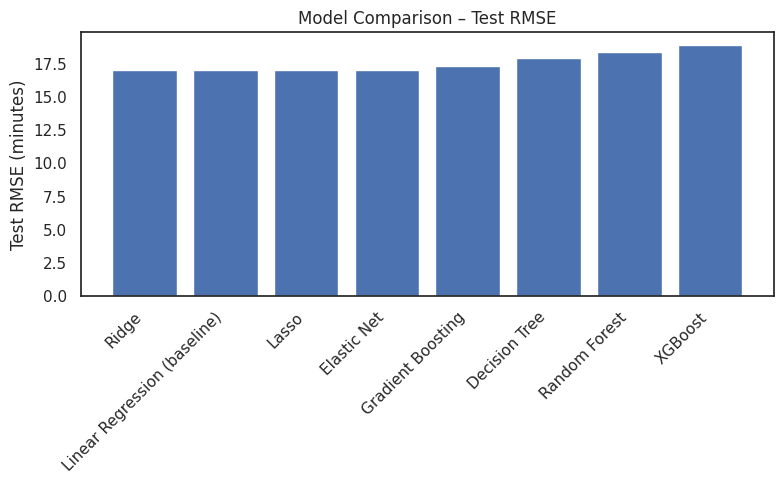

In [ ]:
# bar chart comparing each model's Test RMSE
plt.figure(figsize=(8, 5))
plt.bar(all_results_df["Model"], all_results_df["Test_RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test RMSE (minutes)")
plt.title("Model Comparison – Test RMSE")
plt.tight_layout()
plt.show()

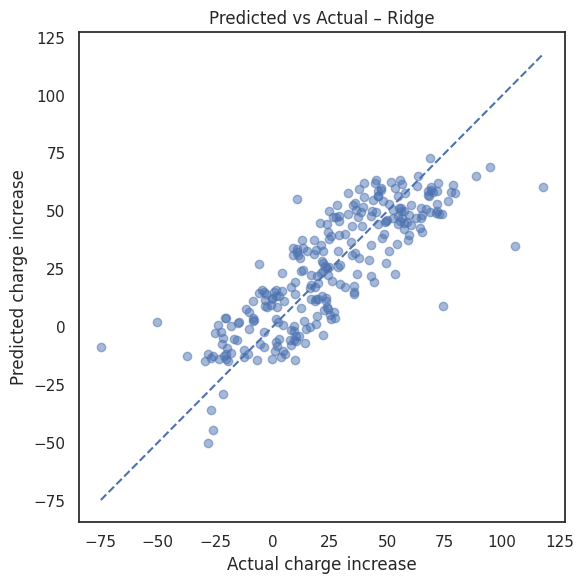

In [ ]:
# pick the row with the lowest Test_RMSE
best_row = all_results_df.iloc[0]
best_model_name = best_row["Model"]

model_lookup = {
    "Linear Regression (baseline)": linreg,
    "Ridge": ridge_best,
    "Lasso": lasso_best,
    "Elastic Net": elastic_best_model,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "Gradient Boosting": best_gbr,
    "XGBoost": xgb,
}

best_model = model_lookup[best_model_name]


# use raw test features (not scaled)
X_test_for_best = X_test

# get predictions for the best model
y_pred_best = best_model.predict(X_test_for_best)

# create scatter plot of actual vs predicted charge increase
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--") # perfect prediction line
plt.xlabel("Actual charge increase")
plt.ylabel("Predicted charge increase")
plt.title(f"Predicted vs Actual – {best_model_name}")
plt.tight_layout()
plt.show()

In [ ]:
# Predict on test set
y_pred = best_rf.predict(X_test)

# Calculate residuals (error) for each test point
residuals = y_test - y_pred

# Absolute errors
abs_errors = np.abs(residuals)

# Report percent in given thresholds (in percentage points)
for threshold in [5, 10, 20]:
    pct = np.mean(abs_errors <= threshold) * 100
    print(f"{pct:.1f}% of predictions are within {threshold} percentage points of SOC increase")

19.3% of predictions are within 5 percentage points of SOC increase
39.0% of predictions are within 10 percentage points of SOC increase
75.8% of predictions are within 20 percentage points of SOC increase


# **Additional Graphics**

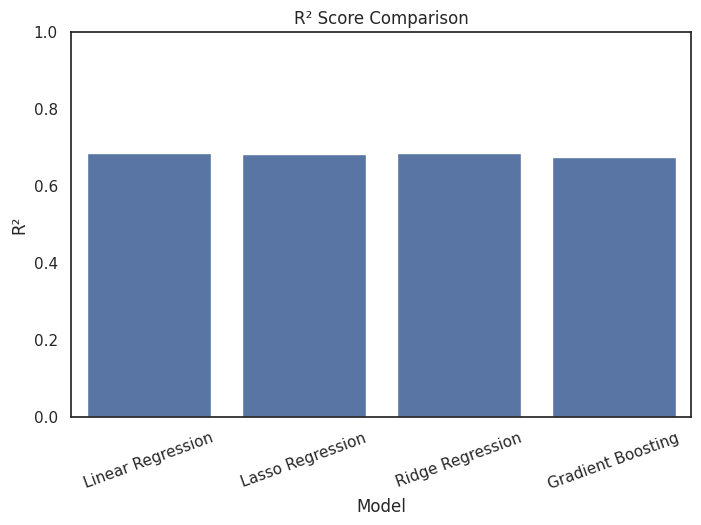

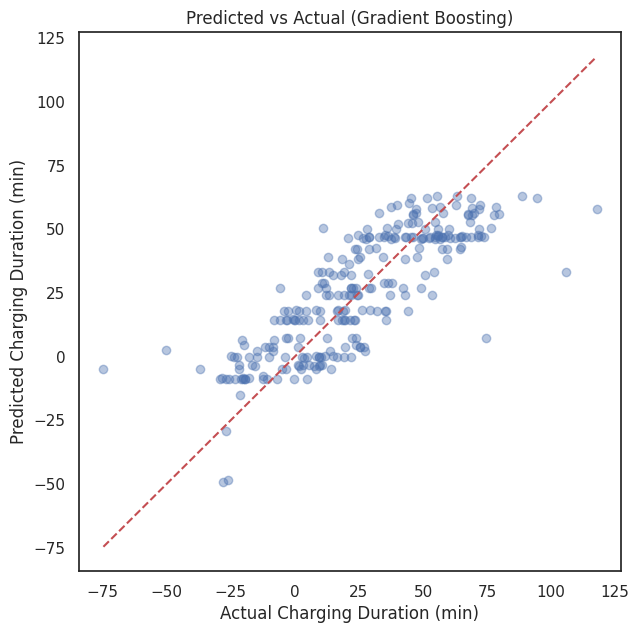

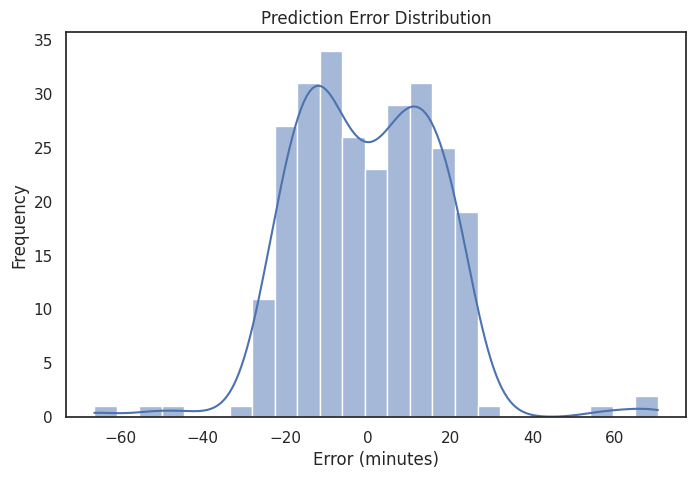

In [ ]:
# R^2 Model Comparison
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="R²")
plt.title("R² Score Comparison")
plt.ylim(0, 1)  # since R² is bounded
plt.xticks(rotation=20)
plt.show()

# Scatter Plot of Predicted Vs Actual Charge Time
plt.figure(figsize=(7,7))
plt.scatter(y_test, gbr_preds, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Charging Duration (min)")
plt.ylabel("Predicted Charging Duration (min)")
plt.title("Predicted vs Actual (Gradient Boosting)")
plt.show()

# Error Distribution Plot
best_model_preds = y_pred_best # Assign the predictions from the best model to best_model_preds
errors = y_test - best_model_preds
plt.figure(figsize=(8,5))
sns.histplot(errors, bins=25, kde=True)
plt.title("Prediction Error Distribution")
plt.xlabel("Error (minutes)")
plt.ylabel("Frequency")
plt.show()



